In [1]:
#Imports & Configurations
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
warnings.filterwarnings("ignore")

#Paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW     = PROJECT_ROOT / "data" / "raw"  / "WA_Fn-UseC_-HR-Employee-Attrition.csv"
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR  = PROJECT_ROOT / "reports" / "figures"
DATA_PROC.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Color palette ──
CLR = {
    "yes"    : "#E24B4A",   # attrition = left
    "no"     : "#1D9E75",   # attrition = stayed
    "blue"   : "#185FA5",
    "orange" : "#EF9F27",
    "purple" : "#8B5CF6",
    "teal"   : "#0EA5A0",
    "gray"   : "#6B7280",
}
SEQ_RED_GREEN = [CLR["yes"], "#F97316", "#FACC15", CLR["no"]]

plt.rcParams.update({
    "figure.dpi"        : 120,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "axes.grid.axis"    : "y",
    "grid.alpha"        : 0.3,
    "font.size"         : 11,
})

def save_png(fig, name):
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"  ✓  PNG → {path}")

def save_html(fig, name):
    path = FIGURES_DIR / name
    fig.write_html(str(path))
    print(f"  ✓  HTML → {path}")

print(f"Project root : {PROJECT_ROOT}")
print(f"Data exists  : {DATA_RAW.exists()}")

Project root : d:\hr-attrition-predictor
Data exists  : True


In [2]:
#Load Raw Data

df=pd.read_csv(DATA_RAW)

#Dropping columns with zero information value
useless = [c for c in df.columns if df[c].nunique()<=1]
df.drop(columns=useless + ["EmployeeNumber"], inplace=True, errors="ignore")

print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(10)

Dataset: 1,470 rows x 31 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,Male,...,3,3,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,3,Female,...,4,1,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,Male,...,4,2,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,4,Male,...,4,2,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,3,Male,...,3,2,2,17,3,2,7,7,7,7


In [3]:
#Section 1 -- Interactive Dashboard

#Dashboard - KPI Summary Cards

total=len(df)
left=(df["Attrition"]=="Yes").sum()
rate=left/total*100
avg_income=df["MonthlyIncome"].mean()
avg_tenure=df["YearsAtCompany"].mean()
avg_age=df["Age"].mean()
avg_sat=df[["JobSatisfaction", "EnvironmentSatisfaction", "RelationshipSatisfaction", "WorkLifeBalance"]].mean().mean()

fig=make_subplots(
    rows=1, cols=6,
    specs=[[{"type" : "indicator"}]*6]
)

kpis = [
    ("Total Employees",    total,        "",    CLR["blue"]),
    ("Employees Left",     left,         "",    CLR["yes"]),
    ("Attrition Rate",     round(rate,1),"%" ,  CLR["orange"]),
    ("Avg Monthly Income", round(avg_income),"$",CLR["teal"]),
    ("Avg Age",            round(avg_age,1),"y", CLR["purple"]),
    ("Avg Tenure",         round(avg_tenure,1),"y",CLR["gray"]),
]

for i, (label, val, suffix, color) in enumerate(kpis, 1):
    fig.add_trace(
        go.Indicator(
            mode="number",
            value=val,
            number={"suffix": suffix, "font": {"size": 32, "color": color}},
            title={"text": f"<b>{label}</b>", "font": {"size": 12, "color": "#374151"}},
        ),
        row=1, col=i
    )

fig.update_layout(
    height=180,
    margin=dict(t=40, b=10, l=10, r=10),
    paper_bgcolor="white",
    title_text="<b>HR Attrition Dashboard — Executive Summary</b>",
    title_font_size=16,
)
save_html(fig, "week2_01_kpi_cards.html")
fig.show()



  ✓  HTML → d:\hr-attrition-predictor\reports\figures\week2_01_kpi_cards.html


In [4]:
#Dashboard -- Attrition by Department & Job Role

dept_rate = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="Attrition Rate (%)")
      .sort_values("Attrition Rate (%)", ascending=False)
)

role_rate = (
    df.groupby("JobRole")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="Attrition Rate (%)")
      .sort_values("Attrition Rate (%)", ascending=True)
)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("<b>Attrition Rate by Department</b>",
                    "<b>Attrition Rate by Job Role</b>"),
    horizontal_spacing=0.12
)

# Department bar
fig.add_trace(
    go.Bar(
        x=dept_rate["Department"],
        y=dept_rate["Attrition Rate (%)"],
        marker_color=[CLR["yes"] if v > rate else CLR["blue"]
                      for v in dept_rate["Attrition Rate (%)"]],
        text=[f"{v:.1f}%" for v in dept_rate["Attrition Rate (%)"]],
        textposition="outside",
        showlegend=False,
    ),
    row=1, col=1
)

# Job Role horizontal bar
fig.add_trace(
    go.Bar(
        y=role_rate["JobRole"],
        x=role_rate["Attrition Rate (%)"],
        orientation="h",
        marker_color=[CLR["yes"] if v > rate else CLR["blue"]
                      for v in role_rate["Attrition Rate (%)"]],
        text=[f"{v:.1f}%" for v in role_rate["Attrition Rate (%)"]],
        textposition="outside",
        showlegend=False,
    ),
    row=1, col=2
)

# Overall average reference line
for col in [1, 2]:
    fig.add_hline(y=rate, line_dash="dash", line_color="gray",
                  annotation_text=f"Avg {rate:.1f}%",
                  annotation_position="top right", row=1, col=col) \
        if col == 1 else \
    fig.add_vline(x=rate, line_dash="dash", line_color="gray",
                  annotation_text=f"Avg {rate:.1f}%",
                  annotation_position="top right", row=1, col=col)

fig.update_layout(
    height=420, paper_bgcolor="white", plot_bgcolor="white",
    margin=dict(t=60, b=40, l=20, r=20),
    yaxis2=dict(tickfont=dict(size=10))
)
fig.update_yaxes(title_text="Attrition Rate (%)", row=1, col=1)
fig.update_xaxes(title_text="Attrition Rate (%)", row=1, col=2)

save_html(fig, "week2_02_dept_role_attrition.html")
fig.show()

  ✓  HTML → d:\hr-attrition-predictor\reports\figures\week2_02_dept_role_attrition.html


In [5]:
#Dashboard -- Monthly Income Analysis

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("<b>Income Distribution by Attrition</b>",
                    "<b>Income by Job Level & Attrition</b>"),
    horizontal_spacing=0.1
)

for label, color in [("Yes", CLR["yes"]), ("No", CLR["no"])]:
    subset = df[df["Attrition"] == label]["MonthlyIncome"]
    fig.add_trace(
        go.Violin(
            x=[label] * len(subset),
            y=subset,
            name=f"Attrition={label}",
            box_visible=True,
            meanline_visible=True,
            fillcolor=color,
            line_color=color,
            opacity=0.7,
        ),
        row=1, col=1
    )

for label, color in [("Yes", CLR["yes"]), ("No", CLR["no"])]:
    subset = df[df["Attrition"] == label]
    fig.add_trace(
        go.Box(
            x=subset["JobLevel"],
            y=subset["MonthlyIncome"],
            name=f"Attrition={label}",
            marker_color=color,
            boxmean=True,
            showlegend=(label == "Yes"),
        ),
        row=1, col=2
    )

fig.update_layout(
    height=420, paper_bgcolor="white", plot_bgcolor="white",
    margin=dict(t=60, b=40),
    legend=dict(title="Attrition", x=0.72, y=0.98),
    violingap=0.3,
)
fig.update_yaxes(title_text="Monthly Income ($)", row=1, col=1)
fig.update_yaxes(title_text="Monthly Income ($)", row=1, col=2)
fig.update_xaxes(title_text="Job Level", row=1, col=2)

save_html(fig, "week2_03_income_analysis.html")
fig.show()

  ✓  HTML → d:\hr-attrition-predictor\reports\figures\week2_03_income_analysis.html


  ✓  PNG → d:\hr-attrition-predictor\reports\figures\week2_04_satisfaction_heatmap.png


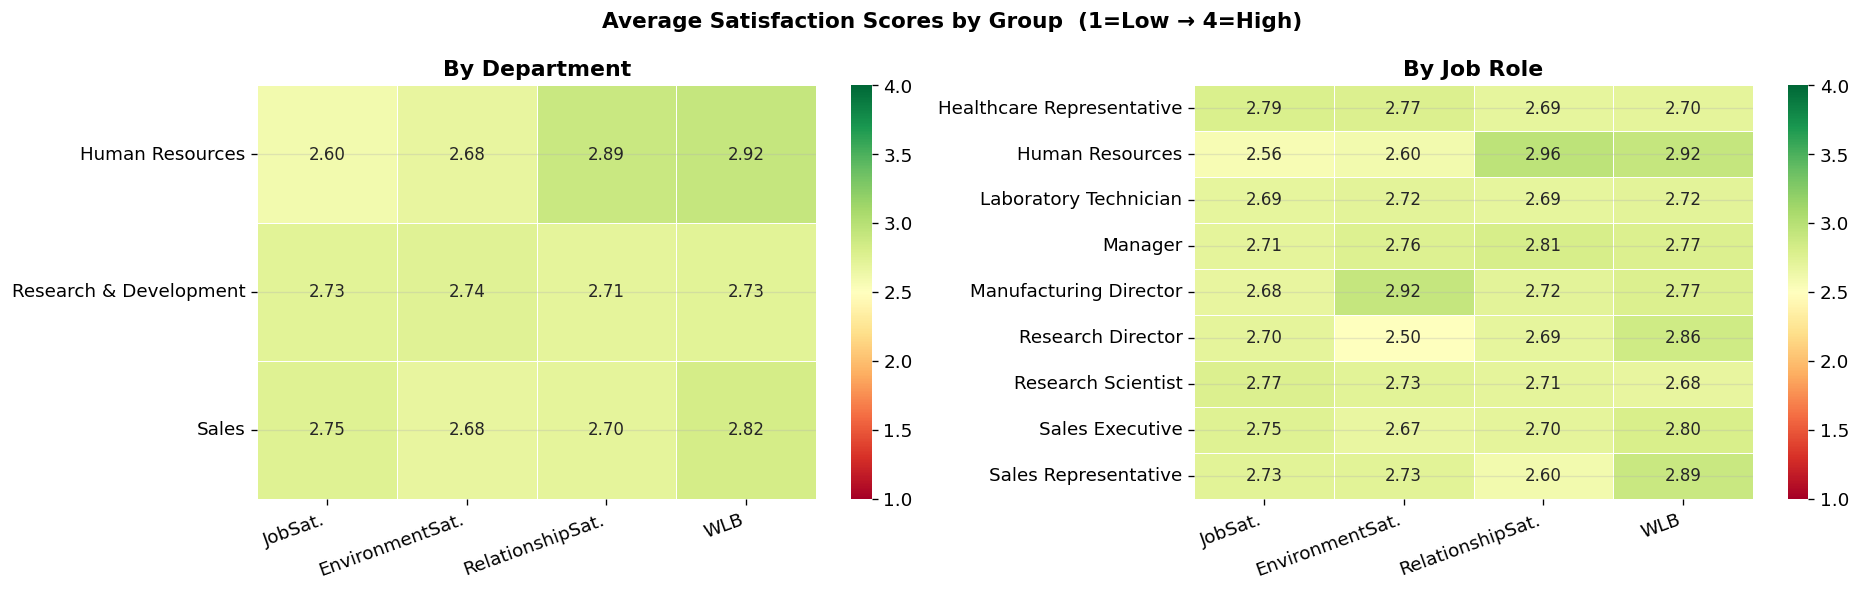

In [6]:
#Dashboard -- Satisfaction Heatmap (Seaborn -- Clearer for grids)
sat_cols   = ["JobSatisfaction", "EnvironmentSatisfaction",
              "RelationshipSatisfaction", "WorkLifeBalance"]
dept_sat   = df.groupby("Department")[sat_cols].mean().round(2)
role_sat   = df.groupby("JobRole")[sat_cols].mean().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Average Satisfaction Scores by Group  (1=Low → 4=High)",
             fontsize=13, fontweight="bold")

for ax, data, title in zip(axes, [dept_sat, role_sat],
                            ["By Department", "By Job Role"]):
    sns.heatmap(
        data, annot=True, fmt=".2f",
        cmap="RdYlGn", vmin=1, vmax=4,
        linewidths=0.5, ax=ax,
        annot_kws={"size": 10}
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xticklabels(
        [c.replace("Satisfaction","Sat.").replace("WorkLifeBalance","WLB")
         for c in sat_cols],
        rotation=20, ha="right"
    )
    ax.set_ylabel("")

plt.tight_layout()
save_png(fig, "week2_04_satisfaction_heatmap.png")
plt.show()

In [7]:
#Dashboard - Age V Income Scatter (Interactive)

fig = px.scatter(
    df,
    x="Age",
    y="MonthlyIncome",
    color="Attrition",
    color_discrete_map={"Yes": CLR["yes"], "No": CLR["no"]},
    size="TotalWorkingYears",
    hover_data=["JobRole", "Department", "JobLevel", "YearsAtCompany"],
    opacity=0.65,
    title="<b>Age vs Monthly Income — Colored by Attrition</b><br>"
          "<sub>Bubble size = Total Working Years</sub>",
    labels={"MonthlyIncome": "Monthly Income ($)", "Age": "Age (years)"}
)
fig.update_layout(
    height=480, paper_bgcolor="white", plot_bgcolor="#F9FAFB",
    legend=dict(title="Attrition"),
    margin=dict(t=80, b=40)
)
fig.update_xaxes(showgrid=True, gridcolor="#E5E7EB")
fig.update_yaxes(showgrid=True, gridcolor="#E5E7EB")

save_html(fig, "week2_05_age_income_scatter.html")
fig.show()

  ✓  HTML → d:\hr-attrition-predictor\reports\figures\week2_05_age_income_scatter.html


In [8]:
#Dashboard -- Overtine & Business Travel Impact
ot_rate = (
    df.groupby(["OverTime", "Department"])["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="Attrition Rate (%)")
)
bt_rate = (
    df.groupby("BusinessTravel")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="Attrition Rate (%)")
      .sort_values("Attrition Rate (%)", ascending=False)
)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "<b>Attrition Rate: OverTime × Department</b>",
        "<b>Attrition Rate by Business Travel</b>"
    ),
    horizontal_spacing=0.14
)

fig.add_trace(
    go.Bar(
        x=ot_rate[ot_rate["OverTime"] == "Yes"]["Department"],
        y=ot_rate[ot_rate["OverTime"] == "Yes"]["Attrition Rate (%)"],
        name="OverTime: Yes",
        marker_color=CLR["yes"],
        text=[f"{v:.1f}%" for v in
              ot_rate[ot_rate["OverTime"] == "Yes"]["Attrition Rate (%)"]],
        textposition="outside",
    ),
    row=1, col=1
)
fig.add_trace(
    go.Bar(
        x=ot_rate[ot_rate["OverTime"] == "No"]["Department"],
        y=ot_rate[ot_rate["OverTime"] == "No"]["Attrition Rate (%)"],
        name="OverTime: No",
        marker_color=CLR["no"],
        text=[f"{v:.1f}%" for v in
              ot_rate[ot_rate["OverTime"] == "No"]["Attrition Rate (%)"]],
        textposition="outside",
    ),
    row=1, col=1
)
fig.add_trace(
    go.Bar(
        x=bt_rate["BusinessTravel"],
        y=bt_rate["Attrition Rate (%)"],
        marker_color=[CLR["yes"], CLR["orange"], CLR["no"]],
        text=[f"{v:.1f}%" for v in bt_rate["Attrition Rate (%)"]],
        textposition="outside",
        showlegend=False,
    ),
    row=1, col=2
)

fig.update_layout(
    height=420, barmode="group",
    paper_bgcolor="white", plot_bgcolor="white",
    legend=dict(title="OverTime"),
    margin=dict(t=60, b=40)
)
fig.update_yaxes(title_text="Attrition Rate (%)", row=1, col=1)
fig.update_yaxes(title_text="Attrition Rate (%)", row=1, col=2)

save_html(fig, "week2_06_overtime_travel.html")
fig.show()

  ✓  HTML → d:\hr-attrition-predictor\reports\figures\week2_06_overtime_travel.html


In [9]:
#Section 2 -- Feature Engineering

#Setup

df_feat=df.copy()

print (f"Starting Feature Engineering...")
print(f"Original Shape: {df_feat.shape}")
print(f"\nColumns before engineering: \n{list(df_feat.columns)}\n")

Starting Feature Engineering...
Original Shape: (1470, 31)

Columns before engineering: 
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']



In [10]:
#Feature 1- Salary_band
# Feature 1 — salary_band
# Income buckets: captures non-linear pay effects on attrition

bins   = [0, 3000, 6000, 10000, df_feat["MonthlyIncome"].max() + 1]
labels = ["Low", "Mid", "High", "Very High"]

df_feat["salary_band"] = pd.cut(
    df_feat["MonthlyIncome"],
    bins=bins, labels=labels, right=False
)

print("salary_band distribution:")
print(df_feat["salary_band"].value_counts().sort_index().to_string())
print("\nAttrition rate by salary_band:")
print(
    df_feat.groupby("salary_band")["Attrition"]
    .apply(lambda x: f"{(x=='Yes').mean()*100:.1f}%")
    .to_string()
)

salary_band distribution:
salary_band
Low          395
Mid          519
High         275
Very High    281

Attrition rate by salary_band:
salary_band
Low          28.6%
Mid          12.7%
High         12.0%
Very High     8.9%


In [11]:
#Feature 2 - Age group
df_feat["age_group"] = pd.cut(
    df_feat["Age"],
    bins=[17, 30, 45, 100],
    labels=["Young (18-30)", "Mid-Career (31-45)", "Experienced (46+)"]
)

print("age_group distribution:")
print(df_feat["age_group"].value_counts().sort_index().to_string())
print("\nAttrition rate by age_group:")
print(
    df_feat.groupby("age_group")["Attrition"]
    .apply(lambda x: f"{(x=='Yes').mean()*100:.1f}%")
    .to_string()
)

age_group distribution:
age_group
Young (18-30)         386
Mid-Career (31-45)    811
Experienced (46+)     273

Attrition rate by age_group:
age_group
Young (18-30)         25.9%
Mid-Career (31-45)    12.7%
Experienced (46+)     12.5%


In [12]:
#Feature 3 --  Distance Band
df_feat["distance_band"] = pd.cut(
    df_feat["DistanceFromHome"],
    bins=[0, 5, 15, 100],
    labels=["Near (1-5 km)", "Moderate (6-15 km)", "Far (16+ km)"]
)

print("distance_band distribution:")
print(df_feat["distance_band"].value_counts().sort_index().to_string())
print("\nAttrition rate by distance_band:")
print(
    df_feat.groupby("distance_band")["Attrition"]
    .apply(lambda x: f"{(x=='Yes').mean()*100:.1f}%")
    .to_string()
)

distance_band distribution:
distance_band
Near (1-5 km)         632
Moderate (6-15 km)    509
Far (16+ km)          329

Attrition rate by distance_band:
distance_band
Near (1-5 km)         13.8%
Moderate (6-15 km)    16.1%
Far (16+ km)          20.7%


In [13]:
#Feature 4 -- Experience Level
df_feat["experience_level"] = pd.cut(
    df_feat["TotalWorkingYears"],
    bins=[-1, 5, 10, 20, 100],
    labels=["Junior (0-5y)", "Mid-Level (6-10y)",
            "Senior (11-20y)", "Expert (21+ y)"]
)

print("experience_level distribution:")
print(df_feat["experience_level"].value_counts().sort_index().to_string())
print("\nAttrition rate by experience_level:")
print(
    df_feat.groupby("experience_level")["Attrition"]
    .apply(lambda x: f"{(x=='Yes').mean()*100:.1f}%")
    .to_string()
)

experience_level distribution:
experience_level
Junior (0-5y)        316
Mid-Level (6-10y)    607
Senior (11-20y)      340
Expert (21+ y)       207

Attrition rate by experience_level:
experience_level
Junior (0-5y)        28.8%
Mid-Level (6-10y)    15.0%
Senior (11-20y)      11.5%
Expert (21+ y)        7.7%


In [14]:
#Feature 5 --  Tenure Ratio

df_feat["tenure_ratio"] = (
    df_feat["YearsAtCompany"] / (df_feat["TotalWorkingYears"] + 1)
).round(3)

print("tenure_ratio stats:")
print(df_feat["tenure_ratio"].describe().round(3).to_string())
print(f"\nMean tenure_ratio by Attrition:")
print(df_feat.groupby("Attrition")["tenure_ratio"].mean().round(3).to_string())

tenure_ratio stats:
count    1470.000
mean        0.582
std         0.284
min         0.000
25%         0.368
50%         0.636
75%         0.833
max         0.976

Mean tenure_ratio by Attrition:
Attrition
No     0.593
Yes    0.522


In [15]:
#Feature 6 -- Satisfaction Index
sat_cols = ["JobSatisfaction", "EnvironmentSatisfaction",
            "RelationshipSatisfaction", "WorkLifeBalance"]

df_feat["satisfaction_index"] = df_feat[sat_cols].mean(axis=1).round(2)

print("satisfaction_index stats:")
print(df_feat["satisfaction_index"].describe().round(2).to_string())
print(f"\nMean satisfaction_index by Attrition:")
print(df_feat.groupby("Attrition")["satisfaction_index"].mean().round(3).to_string())

satisfaction_index stats:
count    1470.00
mean        2.73
std         0.51
min         1.00
25%         2.50
50%         2.75
75%         3.00
max         4.00

Mean satisfaction_index by Attrition:
Attrition
No     2.766
Yes    2.547


In [16]:
#Feature 7 & 8 -- Binary Risk Flags, viz. overtime_encoded & promotion_lag_risk
# Direct binary signal — overtime is the strongest single predictor
# No promotion in 3+ years = potential stagnation signal
df_feat["overtime_encoded"] = (df_feat["OverTime"] == "Yes").astype(int)

df_feat["promotion_lag_risk"] = (
    df_feat["YearsSinceLastPromotion"] >= 3
).astype(int)

print("overtime_encoded:")
print(df_feat["overtime_encoded"].value_counts().to_string())
print(f"\nAttrition rate (overtime=1): "
      f"{df_feat[df_feat['overtime_encoded']==1]['Attrition'].apply(lambda x: 1 if x=='Yes' else 0).mean()*100:.1f}%")
print(f"Attrition rate (overtime=0): "
      f"{df_feat[df_feat['overtime_encoded']==0]['Attrition'].apply(lambda x: 1 if x=='Yes' else 0).mean()*100:.1f}%")

print("\npromotion_lag_risk:")
print(df_feat["promotion_lag_risk"].value_counts().to_string())
print(f"\nAttrition rate (lag_risk=1): "
      f"{df_feat[df_feat['promotion_lag_risk']==1]['Attrition'].apply(lambda x: 1 if x=='Yes' else 0).mean()*100:.1f}%")
print(f"Attrition rate (lag_risk=0): "
      f"{df_feat[df_feat['promotion_lag_risk']==0]['Attrition'].apply(lambda x: 1 if x=='Yes' else 0).mean()*100:.1f}%")

overtime_encoded:
overtime_encoded
0    1054
1     416

Attrition rate (overtime=1): 30.5%
Attrition rate (overtime=0): 10.4%

promotion_lag_risk:
promotion_lag_risk
0    1097
1     373

Attrition rate (lag_risk=1): 13.7%
Attrition rate (lag_risk=0): 17.0%


In [17]:
#Feature Summary -- All 8 new features at a glance.
new_features = [
    "salary_band", "age_group", "distance_band", "experience_level",
    "tenure_ratio", "satisfaction_index", "overtime_encoded", "promotion_lag_risk"
]

print(f"{'Feature':<25}  {'Type':<12}  {'Unique Values / Range'}")
print("─" * 70)
for f in new_features:
    dtype = str(df_feat[f].dtype)
    if dtype in ["float64", "int64", "int32"]:
        rng = f"{df_feat[f].min():.2f} – {df_feat[f].max():.2f}"
    else:
        rng = str(list(df_feat[f].cat.categories))
    print(f"  {f:<23}  {dtype:<12}  {rng}")

print(f"\nDataset shape after engineering: {df_feat.shape}")

# Quick preview
df_feat[["Age","MonthlyIncome","OverTime","Attrition"] + new_features].head(5)

Feature                    Type          Unique Values / Range
──────────────────────────────────────────────────────────────────────
  salary_band              category      ['Low', 'Mid', 'High', 'Very High']
  age_group                category      ['Young (18-30)', 'Mid-Career (31-45)', 'Experienced (46+)']
  distance_band            category      ['Near (1-5 km)', 'Moderate (6-15 km)', 'Far (16+ km)']
  experience_level         category      ['Junior (0-5y)', 'Mid-Level (6-10y)', 'Senior (11-20y)', 'Expert (21+ y)']
  tenure_ratio             float64       0.00 – 0.98
  satisfaction_index       float64       1.00 – 4.00
  overtime_encoded         int64         0.00 – 1.00
  promotion_lag_risk       int64         0.00 – 1.00

Dataset shape after engineering: (1470, 39)


,Age,MonthlyIncome,OverTime,Attrition,salary_band,age_group,distance_band,experience_level,tenure_ratio,satisfaction_index,overtime_encoded,promotion_lag_risk
0,41,5993,Yes,Yes,Mid,Mid-Career (31-45),Near (1-5 km),Mid-Level (6-10y),0.667,2.00,1,0
1,49,5130,No,No,Mid,Experienced (46+),Moderate (6-15 km),Mid-Level (6-10y),0.909,3.00,0,0
2,37,2090,Yes,Yes,Low,Mid-Career (31-45),Near (1-5 km),Mid-Level (6-10y),0.000,3.00,1,0
3,33,2909,Yes,No,Low,Mid-Career (31-45),Near (1-5 km),Mid-Level (6-10y),0.889,3.25,1,1
4,27,3468,No,No,Mid,Young (18-30),Near (1-5 km),Mid-Level (6-10y),0.286,2.50,0,0


  ✓  PNG → d:\hr-attrition-predictor\reports\figures\week2_07_new_features_vs_attrition.png


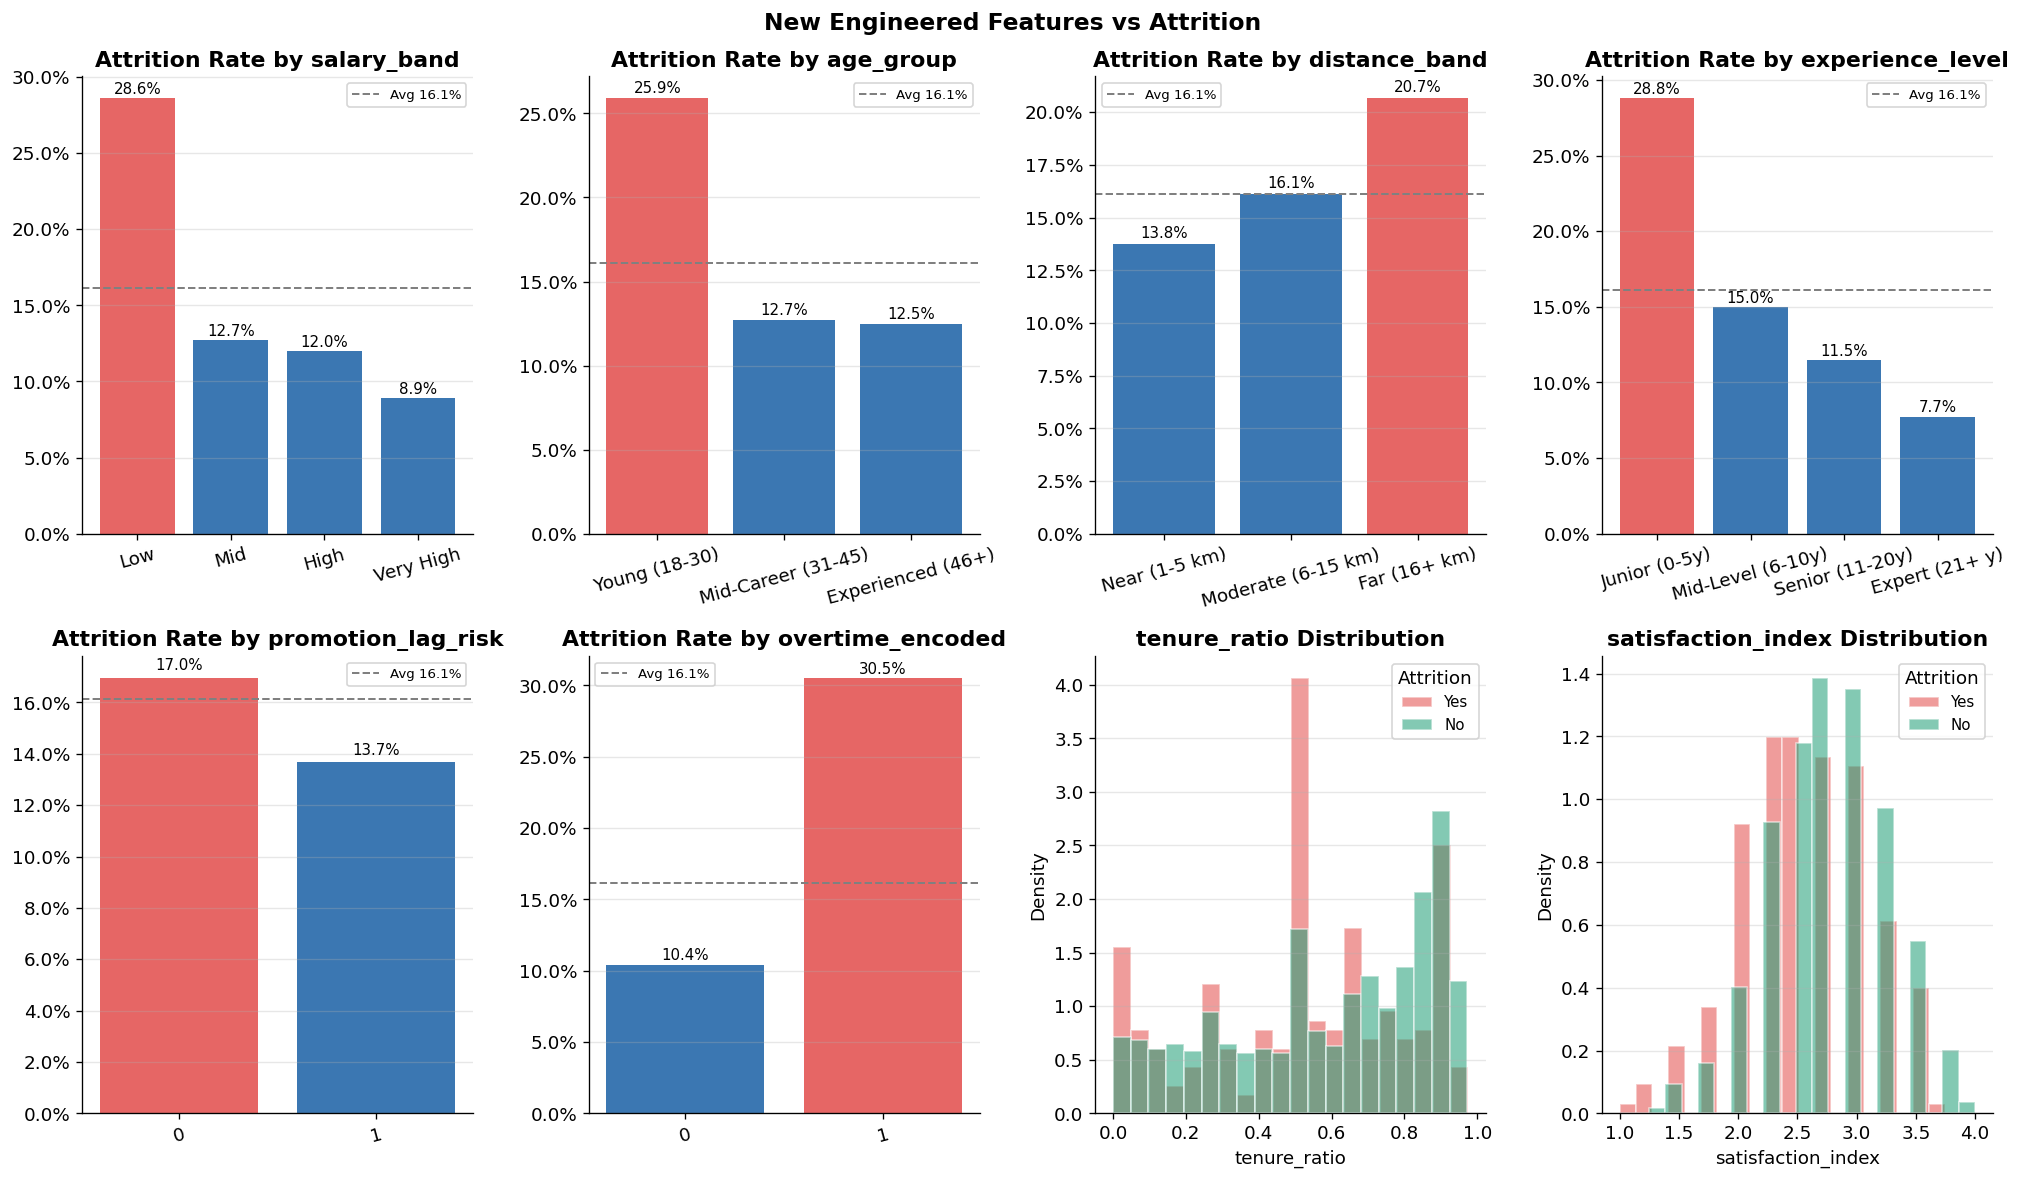

In [20]:
#Visualise new feature vs Attrition
cat_new = ["salary_band", "age_group", "distance_band",
           "experience_level", "promotion_lag_risk", "overtime_encoded"]
num_new = ["tenure_ratio", "satisfaction_index"]

fig, axes = plt.subplots(2, 4, figsize=(17, 10))
axes = axes.flatten()

palette = {"Yes": CLR["yes"], "No": CLR["no"]}
overall_avg = (df_feat["Attrition"] == "Yes").mean() * 100

# Attrition rate for categorical new features
for i, col in enumerate(cat_new):
    rate = (
        df_feat.groupby(col)["Attrition"]
               .apply(lambda x: (x == "Yes").mean() * 100)
               .reset_index(name="rate")
    )
    colors_ = [CLR["yes"] if v > overall_avg else CLR["blue"]
               for v in rate["rate"]]
    axes[i].bar(rate[col].astype(str), rate["rate"],
                color=colors_, alpha=0.85)
    axes[i].axhline(overall_avg, color="gray", linestyle="--",
                    linewidth=1.2, label=f"Avg {overall_avg:.1f}%")
    axes[i].set_title(f"Attrition Rate by {col}", fontweight="bold")
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].legend(fontsize=8)
    for j, v in enumerate(rate["rate"]):
        axes[i].text(j, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)
    axes[i].tick_params(axis="x", rotation=15)

# Numeric new features — overlapping hist
for i, col in enumerate(num_new, start=len(cat_new)):
    for label, color in palette.items():
        subset = df_feat[df_feat["Attrition"] == label][col]
        axes[i].hist(subset, bins=20, alpha=0.55, label=label,
                     color=color, edgecolor="white", density=True)
    axes[i].set_title(f"{col} Distribution", fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(title="Attrition", fontsize=9)

fig.suptitle("New Engineered Features vs Attrition",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_png(fig, "week2_07_new_features_vs_attrition.png")
plt.show()


In [21]:
#Correlation of New Features with Attrition.

df_corr_check = df_feat.copy()
df_corr_check["Attrition_bin"] = (df_corr_check["Attrition"] == "Yes").astype(int)

# Encode categoricals for correlation
for col in ["salary_band", "age_group", "distance_band", "experience_level"]:
    df_corr_check[col] = df_corr_check[col].cat.codes

numeric_check = ["tenure_ratio", "satisfaction_index", "overtime_encoded",
                 "promotion_lag_risk", "salary_band", "age_group",
                 "distance_band", "experience_level", "Attrition_bin"]

corr_new = df_corr_check[numeric_check].corr()["Attrition_bin"].drop("Attrition_bin")

print("Correlation of NEW features with Attrition:\n")
print(f"  {'Feature':<25}  {'r':>8}  {'|r|':>8}  Direction")
print("  " + "─" * 60)
for feat, val in corr_new.abs().sort_values(ascending=False).items():
    raw = corr_new[feat]
    direction = "↑ higher = more attrition" if raw > 0 else "↓ lower = more attrition"
    print(f"  {feat:<25}  {raw:>8.3f}  {val:>8.3f}  {direction}")

Correlation of NEW features with Attrition:

  Feature                           r       |r|  Direction
  ────────────────────────────────────────────────────────────
  overtime_encoded              0.246     0.246  ↑ higher = more attrition
  salary_band                  -0.176     0.176  ↓ lower = more attrition
  experience_level             -0.175     0.175  ↓ lower = more attrition
  satisfaction_index           -0.159     0.159  ↓ lower = more attrition
  age_group                    -0.133     0.133  ↓ lower = more attrition
  tenure_ratio                 -0.092     0.092  ↓ lower = more attrition
  distance_band                 0.071     0.071  ↑ higher = more attrition
  promotion_lag_risk           -0.039     0.039  ↓ lower = more attrition


In [22]:
#Data preprocessing for ML
#Encoding all categorical variables.

# This is the human-readable version for continued EDA / reporting
feat_path = DATA_PROC / "hr_featured.csv"
df_feat.to_csv(feat_path, index=False)
print(f"✓ Featured dataset saved → {feat_path}")
print(f"  Shape: {df_feat.shape}")

✓ Featured dataset saved → d:\hr-attrition-predictor\data\processed\hr_featured.csv
  Shape: (1470, 39)


In [23]:
#Building ML Ready dataset
#Step 1 -- Binary Encoding.

df_ml=df_feat.copy()
binary_map = {
    "Attrition" : {"Yes": 1, "No": 0},
    "OverTime"  : {"Yes": 1, "No": 0},
    "Gender"    : {"Male": 1, "Female": 0},
}
for col, mapping in binary_map.items():
    df_ml[col] = df_ml[col].map(mapping)
    print(f"  Binary encoded: {col}  →  {mapping}")

print()

#Step 2 -- Ordinal encoding (preserve natural order)

ordinal_map = {
    "BusinessTravel": {"Non-Travel": 0, "Travel_Rarely": 1, "Travel_Frequently": 2},
}
for col, mapping in ordinal_map.items():
    df_ml[col] = df_ml[col].map(mapping)
    print(f"  Ordinal encoded: {col}  →  {mapping}")

print()

#Step 3 -- Encode binned categoricals

band_maps = {
    "salary_band"      : {"Low": 0, "Mid": 1, "High": 2, "Very High": 3},
    "age_group"        : {"Young (18-30)": 0, "Mid-Career (31-45)": 1,
                          "Experienced (46+)": 2},
    "distance_band"    : {"Near (1-5 km)": 0, "Moderate (6-15 km)": 1,
                          "Far (16+ km)": 2},
    "experience_level" : {"Junior (0-5y)": 0, "Mid-Level (6-10y)": 1,
                          "Senior (11-20y)": 2, "Expert (21+ y)": 3},
}
for col, mapping in band_maps.items():
    df_ml[col] = df_ml[col].map(mapping)
    print(f"  Band encoded   : {col}  →  {mapping}")

print()

#Step 4 -- Label encode remaining nominal categoricals
nominal_cols = ["Department", "EducationField", "JobRole", "MaritalStatus"]
le = LabelEncoder()
for col in nominal_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    print(f"  Label encoded  : {col}")

print(f"\nAll columns now numeric: {df_ml.dtypes.unique()}")

  Binary encoded: Attrition  →  {'Yes': 1, 'No': 0}
  Binary encoded: OverTime  →  {'Yes': 1, 'No': 0}
  Binary encoded: Gender  →  {'Male': 1, 'Female': 0}

  Ordinal encoded: BusinessTravel  →  {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}

  Band encoded   : salary_band  →  {'Low': 0, 'Mid': 1, 'High': 2, 'Very High': 3}
  Band encoded   : age_group  →  {'Young (18-30)': 0, 'Mid-Career (31-45)': 1, 'Experienced (46+)': 2}
  Band encoded   : distance_band  →  {'Near (1-5 km)': 0, 'Moderate (6-15 km)': 1, 'Far (16+ km)': 2}
  Band encoded   : experience_level  →  {'Junior (0-5y)': 0, 'Mid-Level (6-10y)': 1, 'Senior (11-20y)': 2, 'Expert (21+ y)': 3}

  Label encoded  : Department
  Label encoded  : EducationField
  Label encoded  : JobRole
  Label encoded  : MaritalStatus

All columns now numeric: [dtype('int64')
 CategoricalDtype(categories=[0, 1, 2, 3], ordered=True, categories_dtype=int64)
 CategoricalDtype(categories=[0, 1, 2], ordered=True, categories_dtype=int64)

In [24]:
print(f"\nTarget distribution:")
print(df_ml["Attrition"].value_counts().rename({1:"Left(1)", 0:"Stayed(0)"}).to_string())
print(f"\nFirst 3 rows:")
df_ml.head(10)


Target distribution:
Attrition
Stayed(0)    1233
Left(1)       237

First 3 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,YearsSinceLastPromotion,YearsWithCurrManager,salary_band,age_group,distance_band,experience_level,tenure_ratio,satisfaction_index,overtime_encoded,promotion_lag_risk
0,41,1,1,1102,2,1,2,1,2,0,...,0,5,1,1,0,1,0.667,2.00,1,0
1,49,0,2,279,1,8,1,1,3,1,...,1,7,1,2,1,1,0.909,3.00,0,0
2,37,1,1,1373,1,2,2,4,4,1,...,0,0,0,1,0,1,0.000,3.00,1,0
3,33,0,2,1392,1,3,4,1,4,0,...,3,0,0,1,0,1,0.889,3.25,1,1
4,27,0,1,591,1,2,1,3,1,1,...,2,2,1,0,0,1,0.286,2.50,0,0
5,32,0,2,1005,1,2,2,1,4,1,...,3,6,1,1,0,1,0.778,3.25,0,1
6,59,0,1,1324,1,3,3,3,3,0,...,0,0,0,2,0,2,0.077,1.75,1,0
7,30,0,1,1358,1,24,1,1,4,1,...,0,0,0,0,2,0,0.500,3.00,0,0
8,38,0,2,216,1,23,3,1,4,1,...,1,8,2,1,2,1,0.818,3.00,0,0
9,36,0,1,1299,1,27,3,3,3,1,...,7,7,1,1,2,2,0.389,2.50,0,1


In [25]:
ml_path = DATA_PROC / "hr_ml_ready.csv"
df_ml.to_csv(ml_path, index=False)
print(f"✓ ML-ready dataset saved → {ml_path}")
print(f"  Shape: {df_ml.shape}")
print(f"  Columns ({len(df_ml.columns)}):\n  {list(df_ml.columns)}")

✓ ML-ready dataset saved → d:\hr-attrition-predictor\data\processed\hr_ml_ready.csv
  Shape: (1470, 39)
  Columns (39):
  ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'salary_band', 'age_group', 'distance_band', 'experience_level', 'tenure_ratio', 'satisfaction_index', 'overtime_encoded', 'promotion_lag_risk']


In [26]:
print("=" * 58)
print("  WEEK 2 SUMMARY")
print("=" * 58)
print(f"""
  SECTION 1 — Dashboard (6 interactive charts)
    ✓  KPI cards    → kpi_cards.html
    ✓  Dept/Role    → dept_role_attrition.html
    ✓  Income       → income_analysis.html
    ✓  Satisfaction → satisfaction_heatmap.png
    ✓  Scatter      → age_income_scatter.html
    ✓  OverTime     → overtime_travel.html

  SECTION 2 — Feature Engineering (8 new features)
    ✓  salary_band         — income tier (Low/Mid/High/Very High)
    ✓  age_group           — career stage (Young/Mid/Experienced)
    ✓  distance_band       — commute category (Near/Moderate/Far)
    ✓  experience_level    — seniority by total years
    ✓  tenure_ratio        — loyalty index (0–1)
    ✓  satisfaction_index  — composite satisfaction score
    ✓  overtime_encoded    — binary OverTime signal
    ✓  promotion_lag_risk  — stagnation flag (3+ yrs no promo)

  SECTION 3 — Data Preprocessing
    ✓  hr_featured.csv   → human-readable with new features
    ✓  hr_ml_ready.csv   → fully encoded, XGBoost-ready

  Saved to:
    data/processed/hr_featured.csv
    data/processed/hr_ml_ready.csv
    reports/figures/week2_*.html / *.png

  ─────────────────────────────────────────────────
  Next → Week 3: XGBoost model + SHAP explainability
    Load: data/processed/hr_ml_ready.csv
    Model: XGBoost with scale_pos_weight (class imbalance)
    Eval: ROC-AUC, Precision, Recall, F1, Confusion Matrix
    Explain: SHAP summary plot, waterfall, dependence plots
  ─────────────────────────────────────────────────
""")
print("=" * 58)
print("  ✅  Week 2 Complete!")
print("=" * 58)

  WEEK 2 SUMMARY

  SECTION 1 — Dashboard (6 interactive charts)
    ✓  KPI cards    → kpi_cards.html
    ✓  Dept/Role    → dept_role_attrition.html
    ✓  Income       → income_analysis.html
    ✓  Satisfaction → satisfaction_heatmap.png
    ✓  Scatter      → age_income_scatter.html
    ✓  OverTime     → overtime_travel.html

  SECTION 2 — Feature Engineering (8 new features)
    ✓  salary_band         — income tier (Low/Mid/High/Very High)
    ✓  age_group           — career stage (Young/Mid/Experienced)
    ✓  distance_band       — commute category (Near/Moderate/Far)
    ✓  experience_level    — seniority by total years
    ✓  tenure_ratio        — loyalty index (0–1)
    ✓  satisfaction_index  — composite satisfaction score
    ✓  overtime_encoded    — binary OverTime signal
    ✓  promotion_lag_risk  — stagnation flag (3+ yrs no promo)

  SECTION 3 — Data Preprocessing
    ✓  hr_featured.csv   → human-readable with new features
    ✓  hr_ml_ready.csv   → fully encoded, XGBoost-re